# Which base stats tend to be higher or lower for Sub-Legendary Pokémon compared to Legendary & mythical Pokémon?
This is a Census study becuase we are given the entire populations data, from this we are able to draw conclusions about the entire population.
Further using this analysis it would hypothetically be possible to determine what a pokemons stats could look like if they where to become legendary or become normal

In [15]:
import pandas as pd
df = pd.read_csv("pokemon.csv")
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 55 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   national_number     1025 non-null   int64  
 1   gen                 1025 non-null   str    
 2   english_name        1025 non-null   str    
 3   japanese_name       1025 non-null   str    
 4   primary_type        1025 non-null   str    
 5   secondary_type      526 non-null    str    
 6   classification      1025 non-null   str    
 7   percent_male        870 non-null    float64
 8   percent_female      870 non-null    float64
 9   height_m            1025 non-null   float64
 10  weight_kg           1025 non-null   float64
 11  capture_rate        1025 non-null   str    
 12  base_egg_steps      1025 non-null   int64  
 13  hp                  1025 non-null   int64  
 14  attack              1025 non-null   int64  
 15  defense             1025 non-null   int64  
 16  sp_attack        

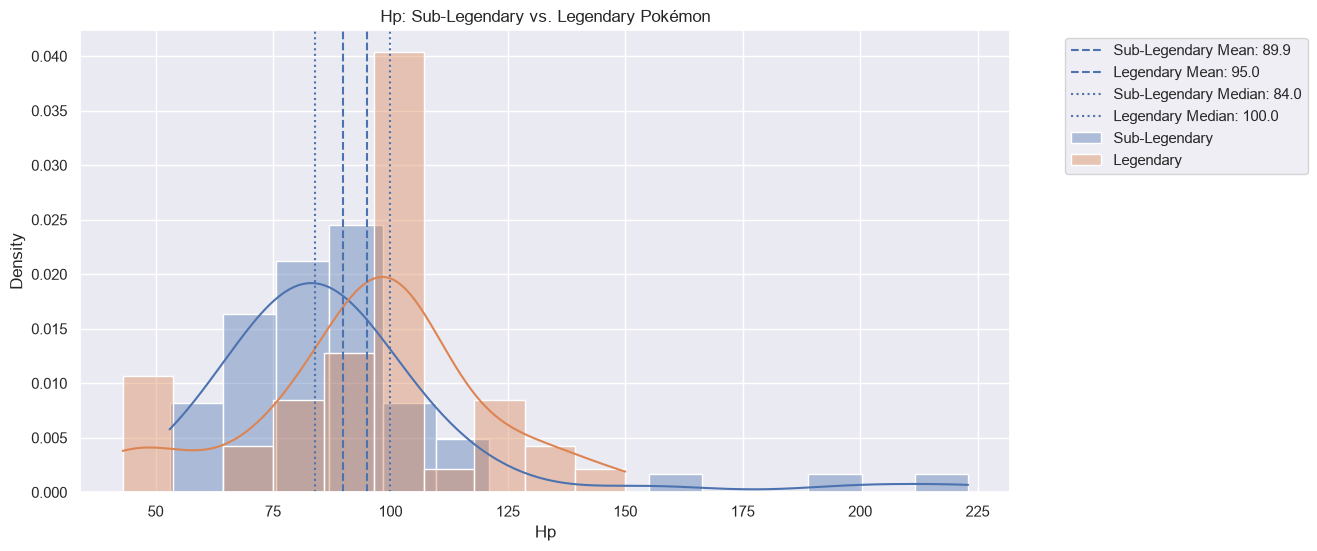


HP
-----------------------------
Sub-Legendary Mean: 89.85
Legendary Mean: 94.98
Mean Difference: 5.13 points

Sub-Legendary Median: 84.00
Legendary Median: 100.00
Median Difference: 16.00 points

Top 5 Pokémon by Hp:
english_name  hp
     Blissey 255
     Chansey 250
    Guzzlord 223
   Regidrago 200
   Wobbuffet 190


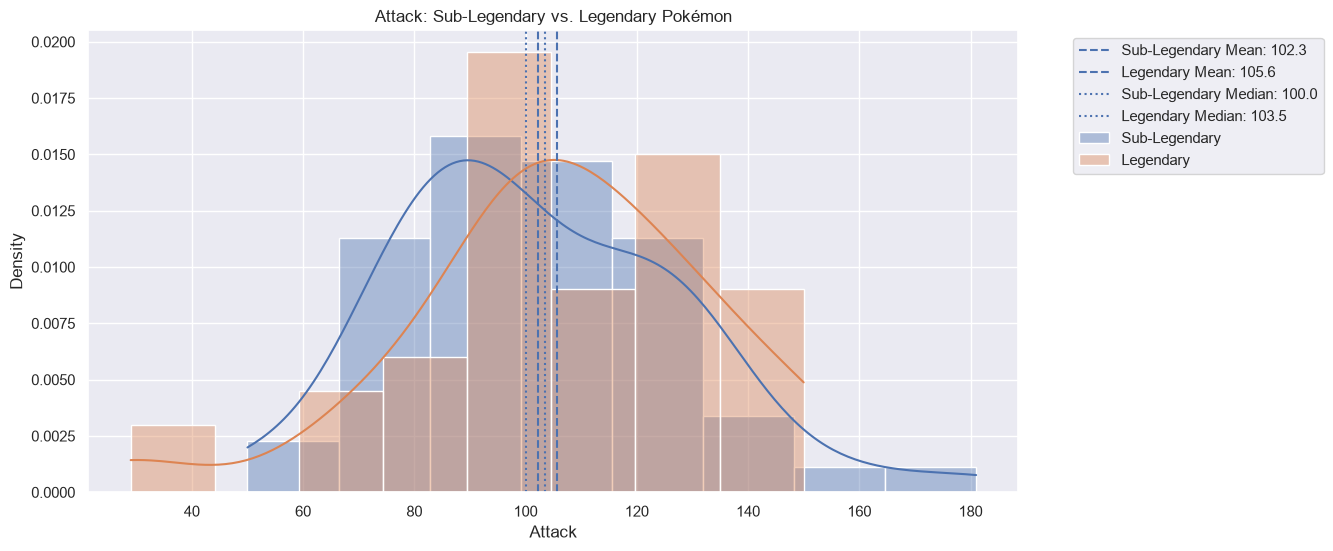


ATTACK
-----------------------------
Sub-Legendary Mean: 102.28
Legendary Mean: 105.59
Mean Difference: 3.31 points

Sub-Legendary Median: 100.00
Legendary Median: 103.50
Median Difference: 3.50 points

Top 5 Pokémon by Attack:
english_name  attack
     Kartana     181
   Rampardos     165
     Slaking     160
   Regigigas     160
     Groudon     150


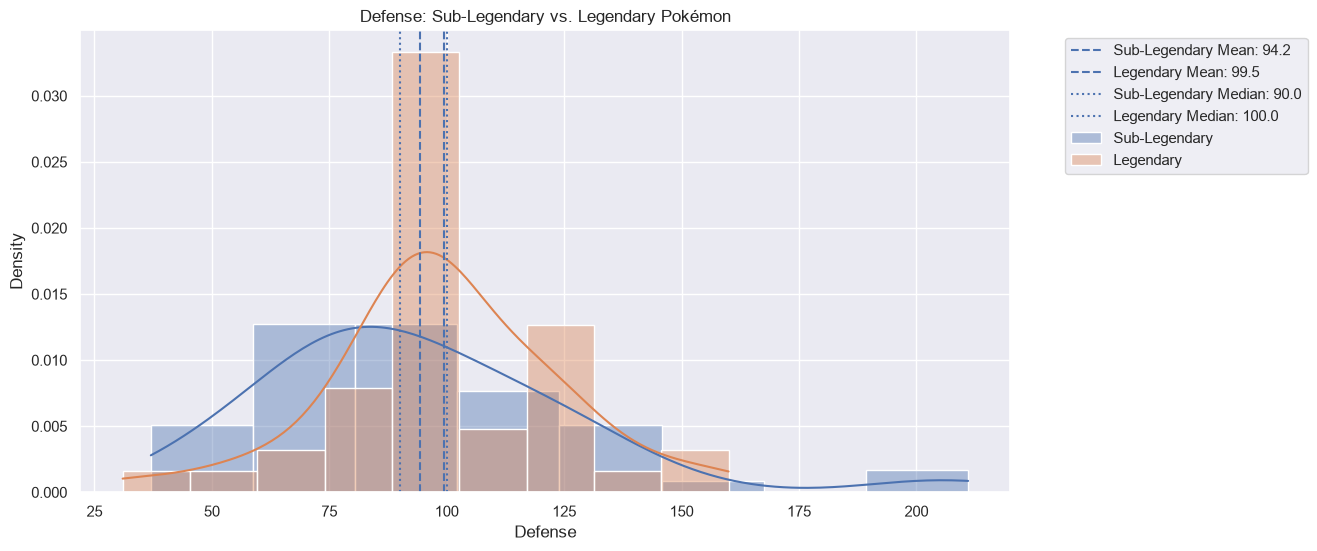


DEFENSE
-----------------------------
Sub-Legendary Mean: 94.24
Legendary Mean: 99.48
Mean Difference: 5.24 points

Sub-Legendary Median: 90.00
Legendary Median: 100.00
Median Difference: 10.00 points

Top 5 Pokémon by Defense:
english_name  defense
     Shuckle      230
   Stakataka      211
     Steelix      200
    Regirock      200
     Avalugg      184


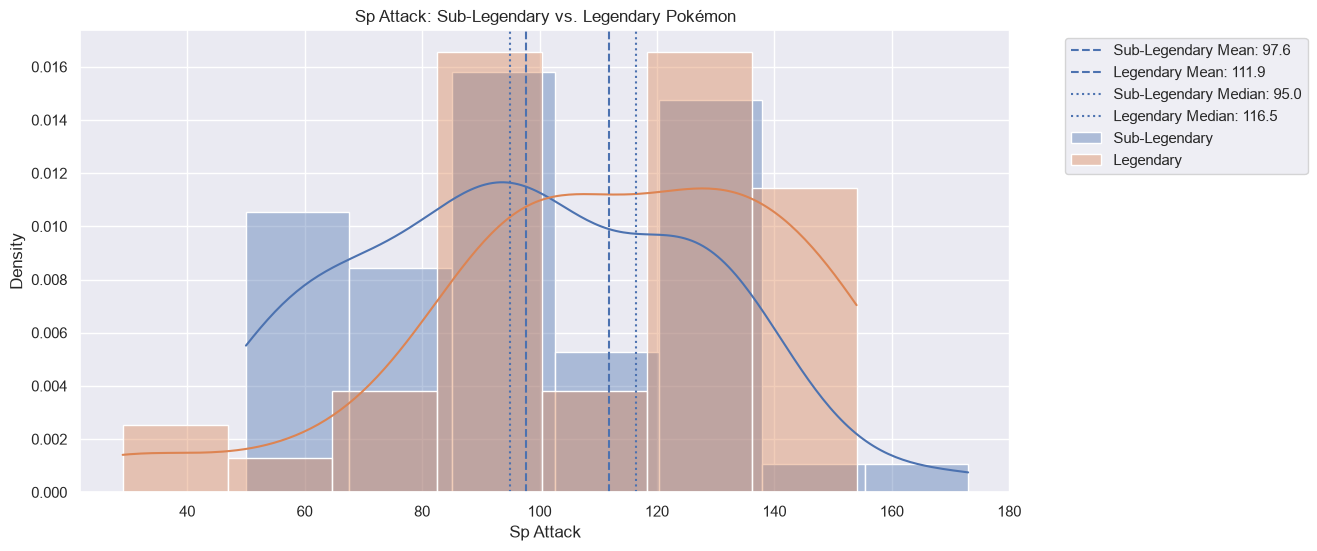


SP_ATTACK
-----------------------------
Sub-Legendary Mean: 97.65
Legendary Mean: 111.91
Mean Difference: 14.26 points

Sub-Legendary Median: 95.00
Legendary Median: 116.50
Median Difference: 21.50 points

Top 5 Pokémon by Sp Attack:
english_name  sp_attack
   Xurkitree        173
      Mewtwo        154
 Blacephalon        151
      Kyogre        150
    Rayquaza        150


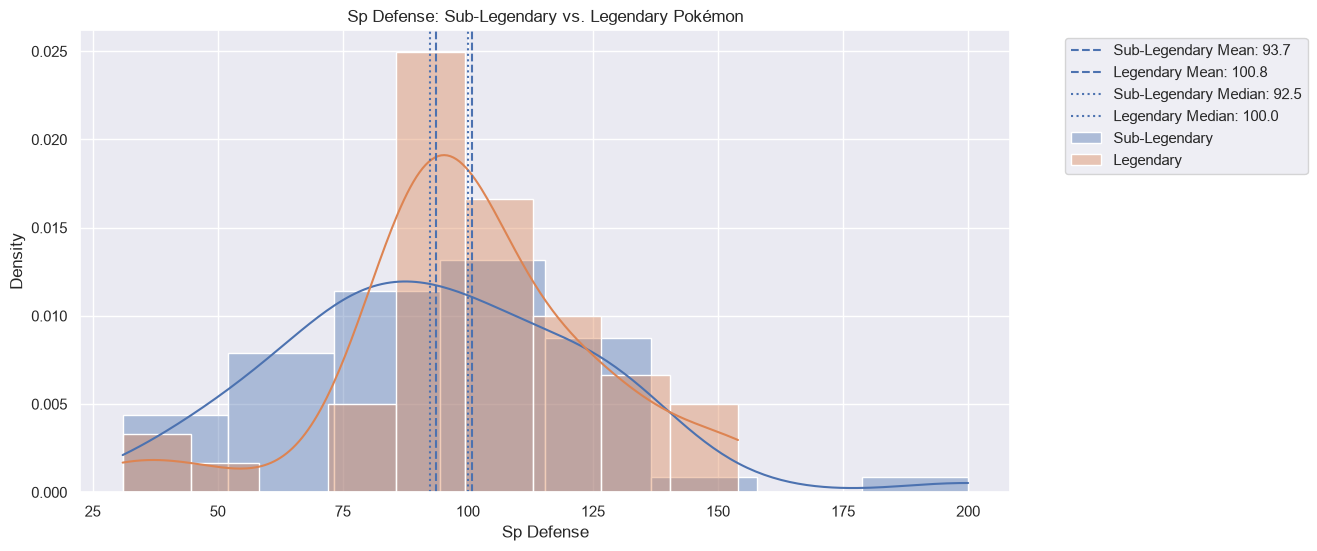


SP_DEFENSE
-----------------------------
Sub-Legendary Mean: 93.72
Legendary Mean: 100.84
Mean Difference: 7.12 points

Sub-Legendary Median: 92.50
Legendary Median: 100.00
Median Difference: 7.50 points

Top 5 Pokémon by Sp Defense:
english_name  sp_defense
     Shuckle         230
      Regice         200
       Lugia         154
       Ho-Oh         154
     Florges         154


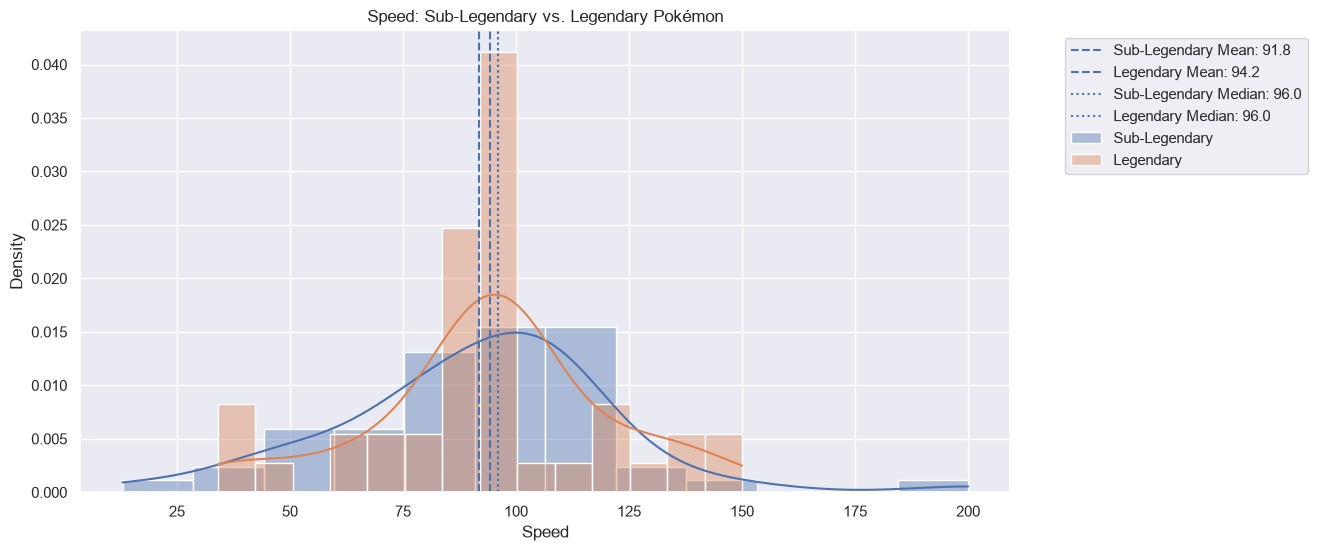


SPEED
-----------------------------
Sub-Legendary Mean: 91.78
Legendary Mean: 94.25
Mean Difference: 2.47 points

Sub-Legendary Median: 96.00
Legendary Median: 96.00
Median Difference: 0.00 points

Top 5 Pokémon by Speed:
english_name  speed
   Regieleki    200
     Ninjask    160
   Pheromosa    151
   Electrode    150
      Deoxys    150

AVERAGE ACROSS ALL 6 STATS
Average Mean Difference: 6.25 points
Average Median Difference: 9.75 points


In [16]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("pokemon.csv")

sns.set_theme()

# Add Mythical Pokémon to the Legendary group
legendary = df[
    (df["is_legendary"] == 1) |
    (df["is_mythical"] == 1)
]

# Sub-Legendary group
sub = df[df["is_sublegendary"] == 1]

# All stats we want to compare
stats = ["hp", "attack", "defense", "sp_attack", "sp_defense", "speed"]

# Lists to store differences
mean_differences = []
median_differences = []

# Make a graph for each stat
for stat in stats:

    # Means
    sub_mean = sub[stat].mean()
    legendary_mean = legendary[stat].mean()

    # Medians
    sub_median = sub[stat].median()
    legendary_median = legendary[stat].median()

    # Differences: Legendary - Sub-Legendary
    mean_difference = legendary_mean - sub_mean
    median_difference = legendary_median - sub_median

    # Store differences
    mean_differences.append(mean_difference)
    median_differences.append(median_difference)

    # Make graph wider
    plt.figure(figsize=(12, 6))

    # Histograms + KDE curves
    sns.histplot(
        data=sub,
        x=stat,
        kde=True,
        stat="density",
        alpha=0.4,
        label="Sub-Legendary"
    )

    sns.histplot(
        data=legendary,
        x=stat,
        kde=True,
        stat="density",
        alpha=0.4,
        label="Legendary"
    )

    # Mean lines
    plt.axvline(
        sub_mean,
        linestyle="--",
        label=f"Sub-Legendary Mean: {sub_mean:.1f}"
    )

    plt.axvline(
        legendary_mean,
        linestyle="--",
        label=f"Legendary Mean: {legendary_mean:.1f}"
    )

    # Median lines
    plt.axvline(
        sub_median,
        linestyle=":",
        label=f"Sub-Legendary Median: {sub_median:.1f}"
    )

    plt.axvline(
        legendary_median,
        linestyle=":",
        label=f"Legendary Median: {legendary_median:.1f}"
    )

    # Labels
    plt.xlabel(stat.replace("_", " ").title())
    plt.ylabel("Density")
    plt.title(
        f"{stat.replace('_', ' ').title()}: "
        "Sub-Legendary vs. Legendary Pokémon"
    )

    # Move legend outside graph
    plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")

    plt.show()

    # Print statistics AFTER the graph
    print(f"\n{stat.upper()}")
    print("-----------------------------")
    print(f"Sub-Legendary Mean: {sub_mean:.2f}")
    print(f"Legendary Mean: {legendary_mean:.2f}")
    print(f"Mean Difference: {mean_difference:.2f} points")
    print()
    print(f"Sub-Legendary Median: {sub_median:.2f}")
    print(f"Legendary Median: {legendary_median:.2f}")
    print(f"Median Difference: {median_difference:.2f} points")

    # Top 5 Pokémon for this stat
    top5 = df.nlargest(5, stat)

    print()
    print(f"Top 5 Pokémon by {stat.replace('_', ' ').title()}:")
    print(top5[["english_name", stat]].to_string(index=False))


# Average difference across all 6 stats
average_mean_difference = sum(mean_differences) / len(mean_differences)
average_median_difference = sum(median_differences) / len(median_differences)

print("\n=============================")
print("AVERAGE ACROSS ALL 6 STATS")
print("=============================")
print(f"Average Mean Difference: {average_mean_difference:.2f} points")
print(f"Average Median Difference: {average_median_difference:.2f} points")

# conclusion
According to this data, the average legendary will have 30 points higher base stats than the average non legendary pokemon (mindblowing data). the graphs also tend to show a trend of no legendary pokemons base stat being skewed to the left or the lower scores, with the legendary pokemon often having a SLIGHT skew to the right just above the global average. interestingly, by base stat there is no consistently domminant pokemon by stat. 
while the next part of this study is likely flawed, the data goes to shows it would have some basis to stand on, to determine what a pokemons stat would look like as a legendary or as a non legendary all one would have to do is add or subtract 26.27 from each stat.

In [19]:
stats = ["hp", "attack", "defense", "sp_attack", "sp_defense", "speed"]

# Create legendary group
legendary_group = df[
    (df["is_legendary"] == 1) | 
    (df["is_mythical"] == 1)
]

# Create non-legendary group
non_legendary_group = df[
    (df["is_legendary"] == 0) & 
    (df["is_mythical"] == 0)
]

# Calculate the mean difference for each stat
mean_difference = (
    legendary_group[stats].mean() - 
    non_legendary_group[stats].mean()
)

# Ask for a Pokémon
name = input("Enter a Pokémon name: ")

# Look up the Pokémon
pokemon = df[df["english_name"].str.lower() == name.lower()]

if pokemon.empty:
    print("Pokémon not found.")

else:
    pokemon = pokemon.iloc[0]

    # Determine current status and automatically choose direction
    if pokemon["is_legendary"] == 1 or pokemon["is_mythical"] == 1:
        current_status = "Legendary"
        new_status = "Now Non-Legendary"
        direction = -1
    else:
        current_status = "Non-Legendary"
        new_status = "Now Legendary"
        direction = 1

    print(f"\n{pokemon['english_name']}")
    print(f"{current_status} -> {new_status}")
    print("\nOld Stats -> New Stats")

    # Adjust every stat
    for stat in stats:
        old_value = pokemon[stat]
        new_value = old_value + (mean_difference[stat] * direction)

        print(f"{stat}: {old_value:.0f} -> {new_value:.1f}")

Enter a Pokémon name:  Azurill



Azurill
Non-Legendary -> Now Legendary

Old Stats -> New Stats
hp: 50 -> 75.9
attack: 20 -> 49.3
defense: 40 -> 68.2
sp_attack: 20 -> 63.7
sp_defense: 40 -> 72.0
speed: 20 -> 48.3
